In [1]:
import torch
import torch.nn as nn 
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from torch.utils.tensorboard import SummaryWriter

import torchvision
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from torchvision.ops import Conv2dNormActivation

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sn 
import matplotlib.pyplot as plt
import time
import numpy as np 
import random
import warnings
import os
from tqdm import tqdm

import pandas as pd

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(42)

In [14]:
class TrainConfig:
    batch_size: int = 32
    num_epochs: int = 100
    learning_rate: float = 1e-4

    log_interval: int = 1
    test_interval: int = 1
    data_root : int = "./"
    num_workers : int = 5
    device : str = "mps"

train_config = TrainConfig()
DEVICE = torch.device("mps") if torch.mps.is_available() else "cpu"
print(f"DEVICE IS {DEVICE}")

DEVICE IS mps


In [15]:
train_root = os.path.join("/Users/snucsnl/Desktop/computer_vision/data/10_monkey", "training", "training")
val_root = os.path.join(train_config.data_root, "/Users/snucsnl/Desktop/computer_vision/data/10_monkey", "validation", "validation")

df = pd.read_csv(os.path.join("/Users/snucsnl/Desktop/computer_vision/data/10_monkey","monkey_labels.txt"), sep=",", header=None)
df.columns = ["Label", "Latin Name", "Common Name", "Train Images", "Validation Images"]
df['Latin Name'] = df['Latin Name'].str.replace("\t", " ")
df[1:]

,Label,Latin Name,Common Name,Train Images,Validation Images
1,n0,alouatta_palliata,mantled_howler,131,26
2,n1,erythrocebus_patas,patas_monkey,139,28
3,n2,cacajao_calvus,bald_uakari,137,27
4,n3,macaca_fuscata,japanese_macaque,152,30
5,n4,cebuella_pygmea,pygmy_marmoset,131,26
6,n5,cebus_capucinus,white_headed_capuchin,141,28
7,n6,mico_argentatus,silvery_marmoset,132,26
8,n7,saimiri_sciureus,common_squirrel_monkey,142,28
9,n8,aotus_nigriceps,black_headed_night_monkey,133,27
10,n9,trachypithecus_johnii,nilgiri_langur,132,26


In [16]:
# 채널간으로 z normalisation 을 걸어서 이미지간의 차이를 두드러지게 드러냄.

mean = [0.4368, 0.4336, 0.3294]  #mean and std of this Monkey Species dataset
std = [0.2457, 0.2413, 0.2447]

img_size = (224, 224)

preprocess = transforms.Compose(
    [
        transforms.Resize(img_size, antialias=True),
        transforms.ToTensor()
    ]
)

/Users/snucsnl/Desktop/computer_vision/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [17]:
common_transforms=transforms.Compose(
    [
        preprocess,
        transforms.Normalize(mean=mean, std=std)
    ]
)

train_transforms=transforms.Compose(
    [
        preprocess,
        transforms.RandomHorizontalFlip(),
        transforms.RandomErasing(p=0.4),
        transforms.RandomApply([
        transforms.RandomAffine(degrees=(30, 70), translate=(0.1, 0.3), scale=(0.5, 0.75)),
        ], p =0.1),
        transforms.Normalize(mean=mean, std=std)

    ]
)

In [18]:
train_data = datasets.ImageFolder(root=train_root,transform=train_transforms)
val_data = datasets.ImageFolder(root=val_root, transform=common_transforms)
train_data.classes

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']

In [19]:
train_data.class_to_idx

{'n0': 0,
 'n1': 1,
 'n2': 2,
 'n3': 3,
 'n4': 4,
 'n5': 5,
 'n6': 6,
 'n7': 7,
 'n8': 8,
 'n9': 9}

In [20]:
len(train_data)

1097

In [25]:
train_loader = DataLoader(
    train_data,
    shuffle=True,
    batch_size=train_config.batch_size,
    num_workers=train_config.num_workers
)

val_loader=DataLoader(
    val_data,
    shuffle=True,
    batch_size=train_config.batch_size,
    num_workers=train_config.num_workers
)

In [26]:
len(next(iter(train_loader)))

2

In [27]:
class_mapping = {

    0: "mantled_howler",
    1: "patas_monkey",
    2: "bald_uakari",
    3: "japanese_macaque",
    4: "pygmy_marmoset",
    5: "white_headed_capuchin",
    6: "silvery_marmoset",
    7: "common_squirrel_monkey",
    8: "black_headed_night_monkey",
    9: "nilgiri_langur"
}

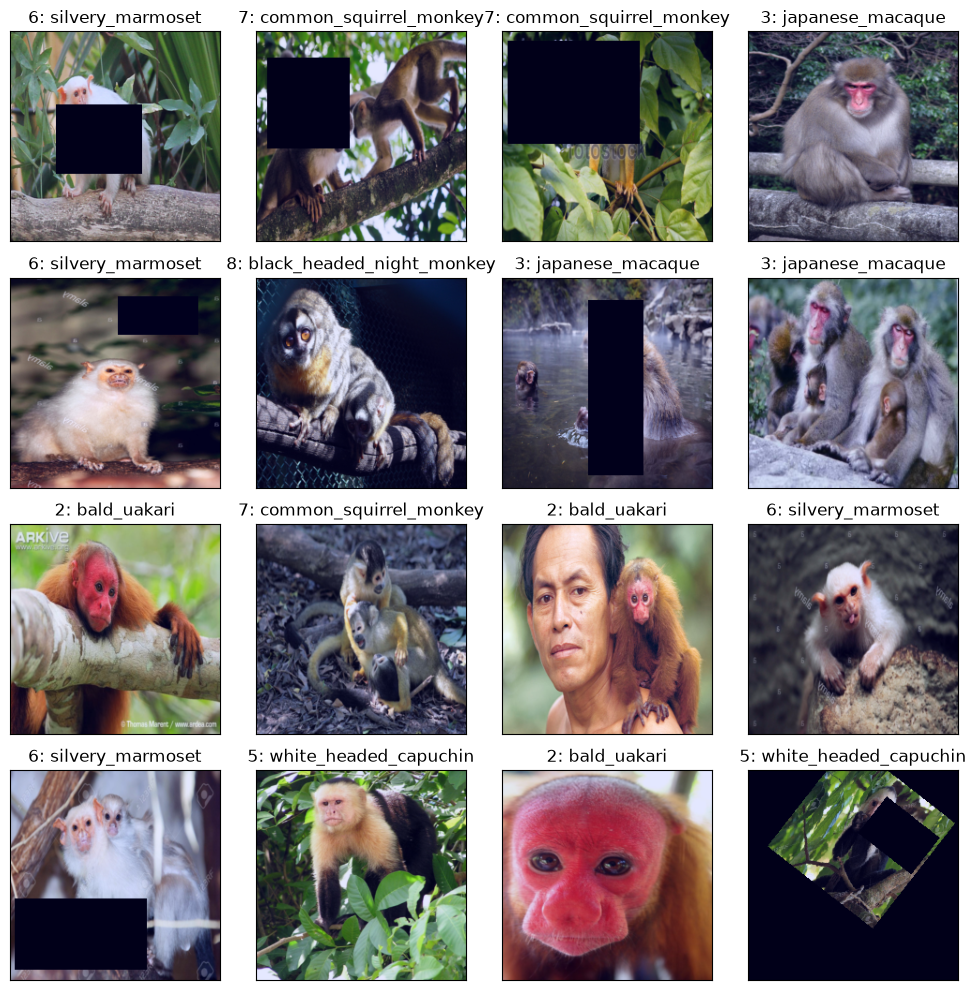

In [28]:
def visualize_images(dataloader, num_images = 20):
    fig = plt.figure(figsize=(10,10))

    #Iterate over the first batch
    images, labels = next(iter(dataloader))
    # print(images.shape)

    num_rows = 4
    num_cols = int(np.ceil((num_images / num_rows)))

    for idx in range(min(num_images, len(images))):
        image, label = images[idx], labels[idx]


        ax = fig.add_subplot(num_rows, num_cols, idx+1, xticks = [], yticks = [])

        image = image.permute(1,2,0)

        #Normalize the image to [0,1] to display

        image = (image - image.min()) / (image.max() - image.min())
        ax.imshow(image, cmap="gray")  # remove the batch dimension
        ax.set_title(f"{label.item()}: {class_mapping[label.item()]}")

    fig.tight_layout()
    plt.show()

visualize_images(train_loader, num_images = 16)



In [31]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self._model=nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=32,kernel_size=5),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=32,out_channels=32,kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.LazyConv2d(out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.LazyConv2d(out_channels=128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            Conv2dNormActivation(in_channels=128,out_channels=256,kernel_size=3),
            Conv2dNormActivation(in_channels=256,out_channels=256,kernel_size=3),
            nn.MaxPool2d(kernel_size=2),
            Conv2dNormActivation(in_channels=256,out_channels=512,kernel_size=3),
            nn.MaxPool2d(kernel_size=2),
            nn.AdaptiveAvgPool2d(output_size=(3,3)),
            nn.Flatten(),
            nn.Linear(in_features=512*3*3,out_features=256),
            nn.Linear(in_features=256, out_features=10)
        )

    def forward(self,x):
        return self._model(x)

In [35]:
model =MyModel()

optimizer=Adam(model.parameters(),lr=train_config.learning_rate)
DEVICE=torch.device("mps") if torch.mps.is_available() else "cpu"
logdir="runs/80epochs-3.3M_param_dropout"

writer=SummaryWriter(logdir)
dummy_input=(1,3,224,224)
print(summary(model,dummy_input,row_settings=["var_names"],device="cpu"))

Layer (type (var_name))                  Output Shape              Param #
MyModel (MyModel)                        [1, 10]                   --
├─Sequential (_model)                    [1, 10]                   --
│    └─Conv2d (0)                        [1, 32, 220, 220]         2,432
│    └─BatchNorm2d (1)                   [1, 32, 220, 220]         64
│    └─ReLU (2)                          [1, 32, 220, 220]         --
│    └─MaxPool2d (3)                     [1, 32, 110, 110]         --
│    └─Conv2d (4)                        [1, 32, 108, 108]         9,248
│    └─BatchNorm2d (5)                   [1, 32, 108, 108]         64
│    └─ReLU (6)                          [1, 32, 108, 108]         --
│    └─MaxPool2d (7)                     [1, 32, 54, 54]           --
│    └─Conv2d (8)                        [1, 64, 52, 52]           18,496
│    └─BatchNorm2d (9)                   [1, 64, 52, 52]           128
│    └─ReLU (10)                         [1, 64, 52, 52]           --
│   

In [40]:
def train(model, train_loader):
    model.train()
    model.to(DEVICE)
    running_loss=0
    correct_predictions=0
    total_train_samples=0

    for images, labels in tqdm(train_loader,desc="Training"):
        images,labels=images.to(DEVICE),labels.to(DEVICE)
        optimizer.zero_grad()
        outputs=model(images)
        loss=F.cross_entropy(outputs,labels)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()
        _,predicted=torch.max(outputs.data,dim=1)
        total_train_samples+=labels.shape[0]
        correct_predictions+=(predicted==labels).sum().item()

    train_avg_loss=running_loss/len(train_loader)
    train_accuracy=100*correct_predictions/total_train_samples
    return train_avg_loss,train_accuracy

In [41]:
def validation(model, val_loader):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_val_samples = 0

    for images, labels in tqdm(val_loader, desc="Validation"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.no_grad():
             outputs = model(images)

        loss = F.cross_entropy(outputs, labels)
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, dim=1)
        total_val_samples += labels.shape[0]
        correct_predictions += (predicted == labels).sum().item()

    val_avg_loss = running_loss / len(val_loader)
    val_accuracy = 100 * correct_predictions / total_val_samples
    return val_avg_loss, val_accuracy

In [42]:
def main(model, train_loader, val_loader):
    
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        train_loss, train_accuracy = train(model, train_loader)
        val_loss, val_accuracy = validation(model, val_loader)


        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1:0>2}/{train_config.num_epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Logging metrics to tensorboard
        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_weights =  model.state_dict()
            print(f"Saving best model...💾")
            torch.save(best_weights, "best.pt")

    return train_losses, train_accuracies, val_losses, val_accuracies

In [43]:
train_losses, train_accuracies, val_losses, val_accuracies = main(model, train_loader, val_loader)



Validation: 100%|██████████| 9/9 [00:32<00:00,  3.60s/it]


Epoch 01/100 - Train Loss: 1.9103, Train Accuracy: 30.17% - Val Loss: 1.8535, Val Accuracy: 37.13%
Saving best model...💾


Validation: 100%|██████████| 9/9 [00:32<00:00,  3.57s/it]


Epoch 02/100 - Train Loss: 1.4645, Train Accuracy: 47.13% - Val Loss: 1.3498, Val Accuracy: 51.10%
Saving best model...💾


Validation: 100%|██████████| 9/9 [00:32<00:00,  3.58s/it]


...

Epoch 43/100 - Train Loss: 0.2627, Train Accuracy: 91.52% - Val Loss: 0.6619, Val Accuracy: 81.25%


Validation: 100%|██████████| 9/9 [00:34<00:00,  3.86s/it]


Epoch 44/100 - Train Loss: 0.2155, Train Accuracy: 93.07% - Val Loss: 0.6405, Val Accuracy: 80.51%


Training:  51%|█████▏    | 18/35 [00:27<00:25,  1.51s/it]


FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 3.
Original Traceback (most recent call last):
  File "/Users/snucsnl/Desktop/computer_vision/.venv/lib/python3.11/site-packages/torch/utils/data/_utils/worker.py", line 375, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/Users/snucsnl/Desktop/computer_vision/.venv/lib/python3.11/site-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/snucsnl/Desktop/computer_vision/.venv/lib/python3.11/site-packages/torch/utils/data/_utils/fetch.py", line 54, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/Users/snucsnl/Desktop/computer_vision/.venv/lib/python3.11/site-packages/torchvision/datasets/folder.py", line 245, in __getite

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1,train_config.num_epochs + 1), train_losses, label = "Train Loss")
plt.plot(range(1, train_config.num_epochs + 1), val_losses, label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1,train_config.num_epochs + 1), train_accuracies, label = "Train Accuracy")
plt.plot(range(1, train_config.num_epochs + 1), val_accuracies, label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
model.load_state_dict(torch.load("best.pt"))
model.eval()

In [ ]:
def prediction(model, val_loader):
    
    model.eval()
    model.to(DEVICE)

    all_images, all_labels = [], []
    all_pred_indices, all_pred_probs = [], []

    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.inference_mode():
             outputs = model(images)

        prob = F.softmax(outputs,dim=1)
        pred_indices = prob.data.max(dim=1)[1]
        pred_probs = prob.data.max(dim=1)[0]

        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_pred_indices.append(pred_indices.cpu())
        all_pred_probs.append(pred_probs.cpu())


    return (torch.cat(all_images).numpy(),
            torch.cat(all_labels).numpy(),
            torch.cat(all_pred_indices).numpy(),
            torch.cat(all_pred_probs).numpy())


In [ ]:
def denormalize(image):
    mean_ar = np.array(mean)
    std_ar = np.array(std)
    image = image * std_ar + mean_ar
    return np.clip(image, 0,1)

In [ ]:
def visualise_predictions(sample_images,sample_gt_labels, pred_indices, pred_probs, num_images =5):
    
    fig = plt.figure(figsize = (20,5))

    for i in range(num_images):
        idx = random.randint(0, len(sample_images) -1)
        image = sample_images[idx].transpose(1,2,0) #(C,H,W) --> (H,W,C)
        label = sample_gt_labels[idx]
        pred_idx = pred_indices[idx]
        pred_prob = pred_probs[idx]

        image = denormalize(image)

        ax = fig.add_subplot(1, num_images, i+1)
        ax.imshow(image)
        ax.set_title(f"GT: {class_mapping[label]}\nPred: {class_mapping[pred_idx]} ({pred_prob:.2f})")
        ax.axis('off')

    plt.show()

In [ ]:
val_images, val_gt_labels, pred_indices, pred_probs = prediction(model, val_loader)

visualise_predictions(val_images, val_gt_labels, pred_indices, pred_probs, num_images = 5)

